In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import f1_score

PROJECT_DIR = "/content/drive/MyDrive/Concrete_defects_CNN_v2"
DATA_DIR = os.path.join(PROJECT_DIR, "Data")
DATASET_DIR = os.path.join(DATA_DIR, "dacl1k_raw")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")

assert os.path.exists(DATASET_DIR), f"{DATASET_DIR} not found."
assert os.path.exists(CHECKPOINT_DIR), f"{CHECKPOINT_DIR} not found — train the models first."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [5]:
CLEAN_CSV = os.path.join(DATASET_DIR, "annotations_clean.csv")
csv_candidates = [f for f in os.listdir(DATASET_DIR) if f.endswith(".csv")]
LABELS_CSV = CLEAN_CSV if os.path.exists(CLEAN_CSV) else os.path.join(DATASET_DIR, csv_candidates[0])
df = pd.read_csv(LABELS_CSV)

known_meta_cols = {"img_name", "img_path", "CLASSES", "CLASSES_N", "CLASSES_STRING",
                   "isStatusChanged", "split", "split_bikit", "split_type",
                   "N_Classes", "n_classes", "num_labels"}

label_cols = [c for c in df.columns
              if c not in known_meta_cols and pd.api.types.is_numeric_dtype(df[c])]

split_col = "split_type"
assert split_col in df.columns, f"'{split_col}' not found in columns: {df.columns.tolist()}"
path_col = "img_path" if "img_path" in df.columns else "img_name"
NUM_CLASSES = len(label_cols)

test_df = df[df[split_col] == "test"].reset_index(drop=True)
print("label_cols:", label_cols)
print("test size:", len(test_df))

label_cols: ['NoDamage', 'Crack', 'Efflorescence', 'Rust', 'Spallation', 'BarsExposed']
test size: 219


In [6]:
IMG_SIZE = 224
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

class Dacl1kDataset(Dataset):
    def __init__(self, dataframe, dataset_dir, path_col, label_cols, transform):
        self.df = dataframe.reset_index(drop=True)
        self.dataset_dir = dataset_dir
        self.path_col = path_col
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel_path = row[self.path_col]
        if rel_path.startswith("dacl1k/"):
            rel_path = rel_path[len("dacl1k/"):]
        img_path = os.path.join(self.dataset_dir, rel_path)
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        label = torch.tensor(row[self.label_cols].values.astype("float32"))
        return img, label

BATCH_SIZE = 32
test_dataset = Dacl1kDataset(test_df, DATASET_DIR, path_col, label_cols, eval_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# sanity check
sample_row = test_df.iloc[0]
rel_path = sample_row[path_col]
if rel_path.startswith("dacl1k/"):
    rel_path = rel_path[len("dacl1k/"):]
print(os.path.join(DATASET_DIR, rel_path), os.path.exists(os.path.join(DATASET_DIR, rel_path)))
print(len(test_dataset))

/content/drive/MyDrive/Concrete_defects_CNN_v2/Data/dacl1k_raw/v1/14_001160.jpg True
219


In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def build_resnet18(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [8]:
def evaluate_model(model, loader, label_cols):
    model = model.to(device)
    model.eval()
    criterion = nn.BCEWithLogitsLoss()

    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    total_loss /= len(loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)

    per_class_f1 = {}
    for i, class_name in enumerate(label_cols):
        per_class_f1[class_name] = f1_score(all_labels[:, i], all_preds[:, i], zero_division=0)

    return {
        "loss": total_loss,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "per_class_f1": per_class_f1,
    }

def load_best_and_evaluate(model, model_name, loader, label_cols):
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{model_name}_best.pt")
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    print(f"[{model_name}] loaded best checkpoint from epoch {ckpt['epoch']+1}")
    results = evaluate_model(model, loader, label_cols)
    print(f"[{model_name}] test_loss={results['loss']:.4f}  test_macro_f1={results['macro_f1']:.4f}  test_micro_f1={results['micro_f1']:.4f}")
    for cls, f1 in results["per_class_f1"].items():
        print(f"  {cls:15s} f1={f1:.4f}")
    print()
    return results

In [9]:
simple_cnn = SimpleCNN(num_classes=NUM_CLASSES)
simple_cnn_results = load_best_and_evaluate(simple_cnn, "simple_cnn", test_loader, label_cols)

resnet_frozen = build_resnet18(NUM_CLASSES)
resnet_frozen_results = load_best_and_evaluate(resnet_frozen, "resnet18_frozen", test_loader, label_cols)

resnet_finetuned = build_resnet18(NUM_CLASSES)
resnet_finetuned_results = load_best_and_evaluate(resnet_finetuned, "resnet18_finetuned", test_loader, label_cols)

[simple_cnn] loaded best checkpoint from epoch 15
[simple_cnn] test_loss=0.6489  test_macro_f1=0.1376  test_micro_f1=0.3151
  NoDamage        f1=0.0816
  Crack           f1=0.0000
  Efflorescence   f1=0.0435
  Rust            f1=0.7004
  Spallation      f1=0.0000
  BarsExposed     f1=0.0000

[resnet18_frozen] loaded best checkpoint from epoch 7
[resnet18_frozen] test_loss=0.5464  test_macro_f1=0.4826  test_micro_f1=0.5313
  NoDamage        f1=0.4839
  Crack           f1=0.1348
  Efflorescence   f1=0.5000
  Rust            f1=0.7216
  Spallation      f1=0.5902
  BarsExposed     f1=0.4651

[resnet18_finetuned] loaded best checkpoint from epoch 6
[resnet18_finetuned] test_loss=0.5352  test_macro_f1=0.6483  test_micro_f1=0.6616
  NoDamage        f1=0.7595
  Crack           f1=0.4960
  Efflorescence   f1=0.7297
  Rust            f1=0.7590
  Spallation      f1=0.6391
  BarsExposed     f1=0.5063



In [10]:
comparison = pd.DataFrame({
    "SimpleCNN": {**{"macro_f1": simple_cnn_results["macro_f1"]}, **simple_cnn_results["per_class_f1"]},
    "ResNet18_frozen": {**{"macro_f1": resnet_frozen_results["macro_f1"]}, **resnet_frozen_results["per_class_f1"]},
    "ResNet18_finetuned": {**{"macro_f1": resnet_finetuned_results["macro_f1"]}, **resnet_finetuned_results["per_class_f1"]},
}).T

print(comparison.round(4))

best_model_name = comparison["macro_f1"].idxmax()
print(f"\nBest model by test macro-F1: {best_model_name} ({comparison.loc[best_model_name, 'macro_f1']:.4f})")

                    macro_f1  NoDamage   Crack  Efflorescence    Rust  \
SimpleCNN             0.1376    0.0816  0.0000         0.0435  0.7004   
ResNet18_frozen       0.4826    0.4839  0.1348         0.5000  0.7216   
ResNet18_finetuned    0.6483    0.7595  0.4960         0.7297  0.7590   

                    Spallation  BarsExposed  
SimpleCNN               0.0000       0.0000  
ResNet18_frozen         0.5902       0.4651  
ResNet18_finetuned      0.6391       0.5063  

Best model by test macro-F1: ResNet18_finetuned (0.6483)


In [11]:
RESULTS_PATH = os.path.join(DATA_DIR, "test_results.csv")
comparison.to_csv(RESULTS_PATH)
print("Saved:", RESULTS_PATH)

Saved: /content/drive/MyDrive/Concrete_defects_CNN_v2/Data/test_results.csv


In [12]:
val_df = df[df[split_col] == "val"].reset_index(drop=True)
val_dataset = Dacl1kDataset(val_df, DATASET_DIR, path_col, label_cols, eval_transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(len(val_dataset))

154


In [13]:
def get_probs_and_labels(model, loader):
    model = model.to(device)
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            all_probs.append(probs.cpu())
            all_labels.append(labels)
    return torch.cat(all_probs).numpy(), torch.cat(all_labels).numpy()

# reload fine-tuned best checkpoint (already loaded from earlier, but explicit here for clarity)
finetuned_ckpt = torch.load(os.path.join(CHECKPOINT_DIR, "resnet18_finetuned_best.pt"), map_location=device, weights_only=False)
resnet_finetuned.load_state_dict(finetuned_ckpt["model_state"])

val_probs, val_labels = get_probs_and_labels(resnet_finetuned, val_loader)
print(val_probs.shape, val_labels.shape)

(154, 6) (154, 6)


In [14]:
import numpy as np

thresholds = np.arange(0.05, 0.95, 0.05)
best_thresholds = {}

for i, class_name in enumerate(label_cols):
    best_f1 = -1
    best_t = 0.5
    for t in thresholds:
        preds = (val_probs[:, i] > t).astype(float)
        f1 = f1_score(val_labels[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds[class_name] = best_t
    print(f"{class_name:15s} best_threshold={best_t:.2f}  val_f1={best_f1:.4f}")

NoDamage        best_threshold=0.30  val_f1=0.7619
Crack           best_threshold=0.35  val_f1=0.6237
Efflorescence   best_threshold=0.35  val_f1=0.7863
Rust            best_threshold=0.20  val_f1=0.8108
Spallation      best_threshold=0.20  val_f1=0.6757
BarsExposed     best_threshold=0.35  val_f1=0.6341


In [15]:
test_probs, test_labels = get_probs_and_labels(resnet_finetuned, test_loader)

tuned_preds = np.zeros_like(test_probs)
for i, class_name in enumerate(label_cols):
    t = best_thresholds[class_name]
    tuned_preds[:, i] = (test_probs[:, i] > t).astype(float)

tuned_macro_f1 = f1_score(test_labels, tuned_preds, average="macro", zero_division=0)
tuned_micro_f1 = f1_score(test_labels, tuned_preds, average="micro", zero_division=0)

print(f"Test macro-F1 (tuned thresholds): {tuned_macro_f1:.4f}")
print(f"Test micro-F1 (tuned thresholds): {tuned_micro_f1:.4f}")
print()
for i, class_name in enumerate(label_cols):
    f1 = f1_score(test_labels[:, i], tuned_preds[:, i], zero_division=0)
    print(f"  {class_name:15s} f1={f1:.4f}  (threshold={best_thresholds[class_name]:.2f})")

Test macro-F1 (tuned thresholds): 0.7028
Test micro-F1 (tuned thresholds): 0.7156

  NoDamage        f1=0.7952  (threshold=0.30)
  Crack           f1=0.5522  (threshold=0.35)
  Efflorescence   f1=0.7799  (threshold=0.35)
  Rust            f1=0.8000  (threshold=0.20)
  Spallation      f1=0.7081  (threshold=0.20)
  BarsExposed     f1=0.5814  (threshold=0.35)


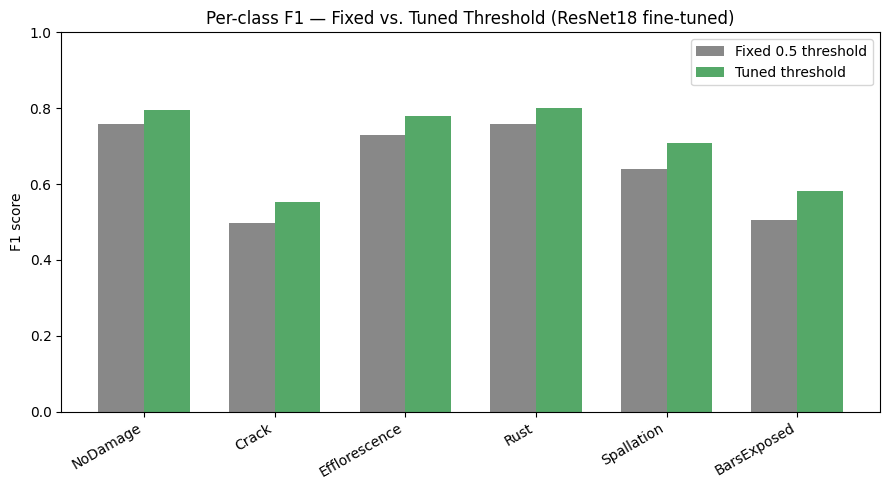

In [19]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(label_cols))
width = 0.35

fixed_f1 = [resnet_finetuned_results["per_class_f1"][c] for c in label_cols]
tuned_f1 = [f1_score(test_labels[:, i], tuned_preds[:, i], zero_division=0) for i, c in enumerate(label_cols)]

ax.bar(x - width/2, fixed_f1, width, label="Fixed 0.5 threshold", color="#888888")
ax.bar(x + width/2, tuned_f1, width, label="Tuned threshold", color="#55a868")

ax.set_xticks(x)
ax.set_xticklabels(label_cols, rotation=30, ha="right")
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1 — Fixed vs. Tuned Threshold (ResNet18 fine-tuned)")
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "threshold_comparison.png"), dpi=150)
plt.show()

In [20]:
import json

thresholds_path = os.path.join(DATA_DIR, "best_thresholds.json")
with open(thresholds_path, "w") as f:
    json.dump(best_thresholds, f, indent=2)
print("Saved:", thresholds_path)

Saved: /content/drive/MyDrive/Concrete_defects_CNN_v2/Data/best_thresholds.json


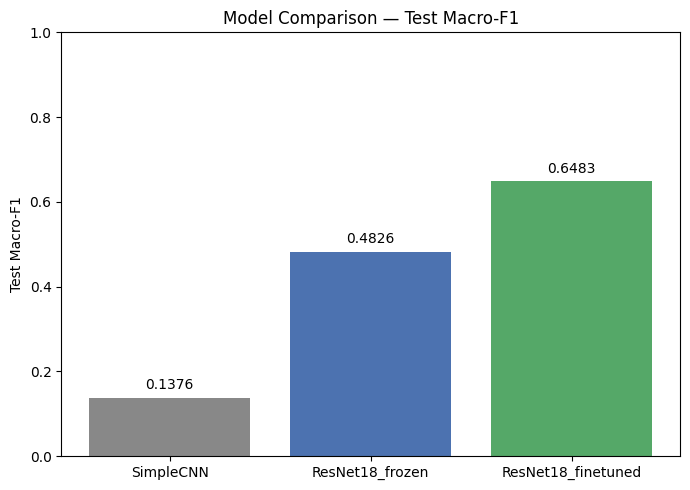

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
models_list = ["SimpleCNN", "ResNet18_frozen", "ResNet18_finetuned"]
macro_f1_values = [comparison.loc[m, "macro_f1"] for m in models_list]

bars = ax.bar(models_list, macro_f1_values, color=["#888888", "#4c72b0", "#55a868"])
ax.set_ylabel("Test Macro-F1")
ax.set_title("Model Comparison — Test Macro-F1")
ax.set_ylim(0, 1)

for bar, val in zip(bars, macro_f1_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.4f}", ha="center")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "model_comparison.png"), dpi=150)
plt.show()